# Daily-gauge detection: Sisimiut and Kangerlussuaq

Two stations of DMI's **manual daily-precipitation network** sit inside the
existing Disko Bay EO box — **34234 Mittarfik Sisimiut** (coastal) and
**34231 Mittarfik Kangerlussuaq** (dry continental, near the ice sheet) — so
this comparison costs no new satellite data. It tests detection at **day
granularity**, which changes the question in a useful way:

- The hourly-gauge comparison fights the gauge's 0.1 mm/h floor and a ±30 min
  window. A *day* of light snow accumulates into something a manual gauge
  reliably measures — precisely the events the hourly comparison scores as
  satellite "false alarms".
- The trade-off, stated honestly: a 24-h accumulation day against 30-second
  snapshots tests *"was the satellite's snow overpass part of a real snow
  day"*, not instantaneous coincidence. Complementary to the hourly result,
  not a replacement.

**Conventions:** the manual gauges stamp at **12 UTC**, covering the
preceding 24 h; day-level phase from the co-located synop's hourly
temperature over the same window (snow day: `t_mean ≤ +1.5 °C`, the same
threshold as everywhere in this project; precip days with `t_mean > 1.5` are
rain and count as satellite-dry reference days). Satellite side: the usual
screening (converged, < 20 mm/h, 1000 m AGL, θ = 0.1 mm/h), a day counts as
satellite-snowing at radius L if **any overpass profile within L during the
accumulation day** is snowing; days with no overpass within L are excluded.

## 1 · Load and build the day-matched tables

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

import sys

sys.path.insert(0, "../src")
import eo_reader as eo

THETA = 0.1
OUTLIER_MMHR = 20.0
SNOW_T = 1.5
RADII = [30, 50, 100]

DAILY_SITES = {
    "sisimiut": dict(csv="../data/in-situ/DMI_API_DATA/34234_daily.csv",
                     lat=66.9514, lon=-53.7231),
    "kangerlussuaq": dict(csv="../data/in-situ/DMI_API_DATA/34231_daily.csv",
                          lat=67.0172, lon=-50.6975),
}

subset = eo.open_subset()          # the Disko box, 9 months of 2025
lat_p = subset["latitude"].values
lon_p = subset["longitude"].values
time_p = pd.to_datetime(subset["time"].values)
rate = subset["snowfall_mmhr_1000m"].values
usable = ((subset["convergence_status"].values == 0)
          & np.isfinite(rate) & (rate < OUTLIER_MMHR))
# accumulation day of each profile: the 12-UTC stamp whose (T-24h, T] covers it
day_p = ((time_p - pd.Timedelta("1ns") + pd.Timedelta(hours=12))
         .floor("D") + pd.Timedelta(hours=12))

site_daily = {}
for site, cfg in DAILY_SITES.items():
    g = pd.read_csv(cfg["csv"], parse_dates=["ts"]).set_index("ts")
    dist = eo.great_circle_km(cfg["lat"], cfg["lon"], lat_p, lon_p)
    rows = []
    for day, gr in g.iterrows():
        if not np.isfinite(gr["precip_mm"]) or gr["t_nobs"] < 12:
            continue
        in_day = usable & np.asarray(day_p == day)
        row = dict(day=day, precip_mm=gr["precip_mm"], t_mean=gr["t_mean"],
                   gauge_snow=bool(gr["precip_mm"] > 0
                                   and gr["t_mean"] <= SNOW_T),
                   gauge_rain=bool(gr["precip_mm"] > 0
                                   and gr["t_mean"] > SNOW_T))
        for L in RADII:
            sel = in_day & (dist <= L)
            row[f"n_prof_{L}"] = int(sel.sum())
            row[f"sat_snow_{L}"] = (bool((rate[sel] > THETA).any())
                                    if sel.any() else None)
        rows.append(row)
    df = pd.DataFrame(rows).set_index("day")
    site_daily[site] = df
    print(f"{site:<14} gauge days {len(df):>3} | snow days "
          f"{int(df.gauge_snow.sum()):>3} | rain days "
          f"{int(df.gauge_rain.sum()):>2} | days with satellite <=100 km: "
          f"{int(df['sat_snow_100'].notna().sum()):>3}")

sisimiut       gauge days 994 | snow days 234 | rain days 183 | days with satellite <=100 km:  99


kangerlussuaq  gauge days 1094 | snow days  74 | rain days 124 | days with satellite <=100 km: 111


## 2 · Day-level contingency

Reference = gauge snow day (daily total > 0, snow phase). Rain days stay in
the sample as "gauge dry for snow" — the satellite's 1 km AGL ice flux on a
rain day is the melt-layer situation and scores as a false alarm here, which
is the honest reading at this reference level.

In [2]:
def contingency(sat_yes, stn_yes):
    hit = int((sat_yes & stn_yes).sum())
    miss = int((~sat_yes & stn_yes).sum())
    fa = int((sat_yes & ~stn_yes).sum())
    cn = int((~sat_yes & ~stn_yes).sum())
    pod = hit / (hit + miss) if hit + miss else np.nan
    far = fa / (hit + fa) if hit + fa else np.nan
    return dict(hit=hit, miss=miss, false_alarm=fa, correct_neg=cn,
                POD=round(pod, 2) if pod == pod else None,
                FAR=round(far, 2) if far == far else None)

rows = []
for site, df in site_daily.items():
    for L in RADII:
        v = df[df[f"sat_snow_{L}"].notna()]
        rows.append(dict(site=site, L_km=L, n_days=len(v),
                         gauge_snow_days=int(v.gauge_snow.sum()),
                         **contingency(v[f"sat_snow_{L}"].astype(bool).values,
                                       v["gauge_snow"].values)))
daily_detection = pd.DataFrame(rows)
pd.set_option("display.width", 200)
daily_detection

,site,L_km,n_days,gauge_snow_days,hit,miss,false_alarm,correct_neg,POD,FAR
0,sisimiut,30,26,9,2,7,5,12,0.22,0.71
1,sisimiut,50,44,15,6,9,7,22,0.40,0.54
2,sisimiut,100,99,35,17,18,23,41,0.49,0.57
3,kangerlussuaq,30,39,2,1,1,4,33,0.50,0.80
4,kangerlussuaq,50,48,4,1,3,6,38,0.25,0.86
5,kangerlussuaq,100,111,13,7,6,26,72,0.54,0.79


## 3 · Season strips

C:\Users\marti\AppData\Local\Temp\ipykernel_21744\1016801273.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


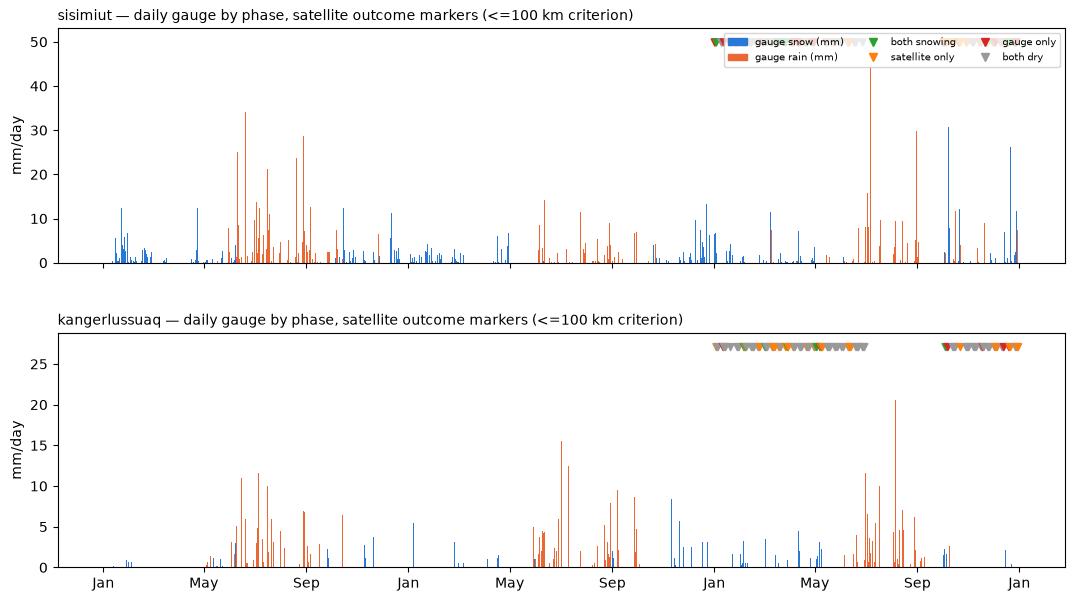

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                         gridspec_kw={"hspace": 0.3})
for ax, (site, df) in zip(axes, site_daily.items()):
    snow_mm = df["precip_mm"].where(df["gauge_snow"], 0)
    rain_mm = df["precip_mm"].where(df["gauge_rain"], 0)
    ax.bar(df.index, snow_mm, width=0.9, color="#2a78d6", label="gauge snow")
    ax.bar(df.index, rain_mm, width=0.9, bottom=snow_mm, color="#eb6834",
           label="gauge rain")
    ymax = max(df["precip_mm"].max() * 1.2, 2)
    v = df[df["sat_snow_100"].notna()]
    sat = v["sat_snow_100"].astype(bool)
    stn = v["gauge_snow"]
    color = np.where(sat & stn, "tab:green",
            np.where(sat & ~stn, "tab:orange",
            np.where(~sat & stn, "tab:red", "0.6")))
    ax.scatter(v.index, np.full(len(v), ymax * 0.94), c=color, s=25,
               marker="v", zorder=5)
    ax.set_ylim(0, ymax)
    ax.set_ylabel("mm/day")
    ax.set_title(f"{site} — daily gauge by phase, satellite outcome markers "
                 "(<=100 km criterion)", loc="left", fontsize=10)
axes[0].legend(handles=[
    Patch(color="#2a78d6", label="gauge snow (mm)"),
    Patch(color="#eb6834", label="gauge rain (mm)"),
    plt.Line2D([], [], marker="v", ls="", color="tab:green", label="both snowing"),
    plt.Line2D([], [], marker="v", ls="", color="tab:orange", label="satellite only"),
    plt.Line2D([], [], marker="v", ls="", color="tab:red", label="gauge only"),
    plt.Line2D([], [], marker="v", ls="", color="0.6", label="both dry"),
], loc="upper right", fontsize=7, ncols=3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
fig.savefig("../figures/eo_dmi_daily_strips.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()

## 4 · Takeaways

- Compare the POD/FAR here against the hourly-gauge sites' tables
  (`compare_earthcare_dmi_stations`): day granularity removes the gauge-floor
  and timing failure modes, so differences between these numbers and the
  hourly ones measure how much of the "disagreement" was instrument/window
  artifact rather than satellite error.
- Kangerlussuaq is the first **continental dry** site in the study — its
  contingency behaviour vs coastal Sisimiut is a climate-regime comparison
  inside a single EO box.
- Both gauges are manual once-daily readings: undercatch still applies
  (unshielded manual gauges in wind), and the 12 UTC accumulation day is
  offset from the calendar day — kept consistently on both sides here.
- If this looks healthy, the same recipe extends to Station Nord,
  Danmarkshavn and Narsarsuaq with one EO sweep each.